# **Project Name**    - Uber Ride Request Analysis



##### **Project Type**    - EDA
##### **Contribution**    - Individual


# **Project Summary -**

Write the summary here within 500-600 words.
# Project Summary

The objective of this project was to analyze Uber ride request data to identify operational inefficiencies, demand-supply gaps, ride cancellation patterns, and driver availability issues. The project aimed to generate actionable business insights that could help improve customer satisfaction, optimize driver allocation, reduce unfulfilled ride requests, and enhance overall operational efficiency. The analysis was performed using Microsoft Excel for data cleaning and dashboard creation, Python for Exploratory Data Analysis (EDA) and visualization, and SQL for querying and extracting meaningful operational insights from the dataset.

The project began with extensive data cleaning and preprocessing to ensure data quality and consistency. Missing values, duplicate records, inconsistent formats, and incorrect timestamp formats were identified and handled appropriately. Date and time values from request timestamps were standardized, and additional features such as request hour, request day, and time slots were extracted to support detailed time-based analysis. Binary flag columns such as Trip_Completed_Flag, Cancelled_Flag, and No_Cars_Available_Flag were also created from the status column to simplify KPI calculations and operational analysis. These engineered features helped improve analytical accuracy and enabled efficient calculation of completion rates, cancellation percentages, and driver unavailability metrics.

Exploratory Data Analysis was conducted using Python libraries such as Pandas, Matplotlib, and Seaborn. Various visualizations including count plots, bar charts, line charts, pair plots, and heatmaps were used to identify ride request trends and operational patterns. One of the major insights obtained from the analysis was that ride requests were highly concentrated during peak commuting hours, particularly during morning and evening periods. These peak periods also showed increased ride cancellations and “No Cars Available” incidents, indicating a significant demand-supply imbalance within Uber’s operations.

These insights create a strong positive business impact because they help identify the exact time periods where operational improvements are required. By understanding peak demand hours, Uber can strategically increase driver availability during those periods, reducing customer waiting time and improving ride fulfillment rates. Better driver allocation during high-demand periods can directly improve customer satisfaction, increase completed rides, and enhance revenue generation for the company.

Further analysis of driver availability showed that the number of active drivers did not increase proportionally with rising customer demand during peak hours. A comparative line chart between active drivers and total ride requests clearly highlighted operational shortages during high-demand periods. This imbalance contributed to higher ride cancellations and unfulfilled requests, negatively impacting customer experience and operational efficiency.

The insights from this analysis are highly valuable for operational planning and resource optimization. Identifying driver shortages during specific hours enables Uber to implement targeted driver incentive programs, improve shift scheduling, and optimize supply distribution across pickup locations. These improvements can significantly reduce cancellations and improve platform reliability, creating a positive impact on both customer retention and driver productivity.

Ride duration analysis showed that most rides were concentrated within medium-duration ranges, while extremely long-duration rides were relatively less frequent. Pair Plot analysis was used to study relationships between ride duration, request hour, and operational status indicators. Although no strong linear correlation was observed, the visualization helped identify clustering patterns and operational distributions across ride requests. These insights support better route planning and demand forecasting, helping Uber improve operational efficiency and reduce delays.

SQL queries were used to perform aggregations and extract business metrics such as cancellation percentages, completion rates, day-wise request counts, and hourly demand trends. These queries enabled efficient operational reporting and strengthened analytical understanding of the dataset. The extracted metrics provided measurable indicators that can support strategic decision-making and continuous performance monitoring.

An interactive dashboard was developed in Microsoft Excel using Pivot Tables, Pivot Charts, slicers, KPI cards, and conditional formatting. The dashboard provided dynamic filtering capabilities and visualized key operational metrics including total requests, cancellations, completed trips, no-car availability incidents, and peak-hour demand patterns. Slicers allowed users to interactively analyze trends across different pickup points, statuses, days, and time slots. This dashboard can help management quickly identify operational bottlenecks and make faster data-driven decisions.

The overall findings of the project highlighted that demand-supply imbalance during peak hours was one of the primary operational challenges affecting Uber ride fulfillment. The analysis suggested that improving driver allocation strategies during high-demand periods could significantly reduce ride cancellations, improve ride completion rates, and enhance customer satisfaction. Overall, the insights generated from this project create a positive business impact by supporting operational optimization, improving service quality, increasing customer retention, and enabling more efficient resource management. The project successfully demonstrated the application of Excel, Python, and SQL in solving real-world business problems through data-driven analysis and visualization.


# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**"Analyze Uber ride request data to identify key causes of ride cancellations and unmet demand by examining trip status, pickup locations, and time-based trends, and provide actionable business recommendations to improve ride fulfillment and customer experience."**

#### **Define Your Business Objective?**

The primary business objective of this project is to analyze Uber ride request data to identify operational inefficiencies causing trip cancellations and unmet customer demand.

The analysis aims to:

Identify the major reasons behind ride cancellations and “No Cars Available” requests.
Understand demand-supply gaps across different time periods and pickup locations.
Analyze driver availability patterns during peak and non-peak hours.
Improve ride fulfillment rates and reduce customer dissatisfaction.
Provide data-driven recommendations to optimize driver allocation, scheduling, and operational efficiency.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [30]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date and time handling
from datetime import datetime

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [31]:
# Load Dataset
df = pd.read_csv("Uber Request Data.csv")

### Dataset First View

In [32]:
# Dataset First Look
df.head()


,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


In [33]:
#dataset bottom view
df.tail()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
6740,6745,City,NaN,No Cars Available,15-07-2016 23:49:03,NaN
6741,6752,Airport,NaN,No Cars Available,15-07-2016 23:50:05,NaN
6742,6751,City,NaN,No Cars Available,15-07-2016 23:52:06,NaN
6743,6754,City,NaN,No Cars Available,15-07-2016 23:54:39,NaN
6744,6753,Airport,NaN,No Cars Available,15-07-2016 23:55:03,NaN


### Dataset Rows & Columns count

In [34]:
# Dataset Rows & Columns count
df.shape
print("Number of Rows:",df.shape[0])
print("Number of Columns:",df.shape[1])

Number of Rows: 6745
Number of Columns: 6


### Dataset Information

In [35]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   str    
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   str    
 4   Request timestamp  6745 non-null   str    
 5   Drop timestamp     2831 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 316.3 KB


#### Duplicate Values

In [36]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [37]:
df.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

In [38]:
#Missing value in percentage 
(df.isnull().sum() / len(df)) * 100

Request id            0.000000
Pickup point          0.000000
Driver id            39.288362
Status                0.000000
Request timestamp     0.000000
Drop timestamp       58.028169
dtype: float64

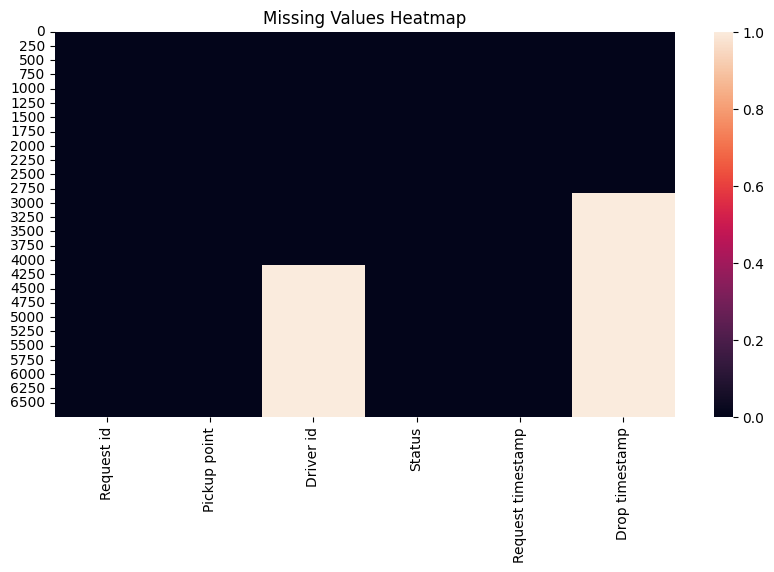

In [39]:
# Visualizing the missing values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=True)
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

From this Uber Technologies ride request dataset, I understand that the data represents customer ride requests and their final outcomes. The dataset is mainly focused on analyzing operational efficiency, driver availability, and customer service performance.

Here is what can be understood from the data:

1. TThe dataset hase 6745 rows and 6 columns

Each row represents one ride request and contains information such as:

Request ID
Pickup location
Driver assignment
Ride status
Request time
Drop time

This helps track whether a ride was:

Successfully completed
Cancelled
Unfulfilled due to no car availability
2. There Is a Significant Demand-Supply Gap

The presence of statuses like:

“Cancelled”
“No Cars Available”
indicates that Uber is unable to fulfill all customer requests efficiently.

This suggests:High customer demand
Insufficient driver supply during certain periods

3. Time Plays a Major Role
The dataset includes timestamps, which means we can analyze:
Peak demand hours
High cancellation periods
Driver shortage timings
Rush-hour operational issues
This is useful for time-based demand forecasting.

4. Pickup Location Impacts Ride Fulfillment
The dataset mainly compares:

Airport pickups
City pickups

This helps determine:
Which location faces more cancellations
Where cars are less available
Which area needs better driver allocation

5. Missing Values Carry Business Meaning
Null values in:

Driver id contains 2650 Null value and Drop timestamp contains 3914 null value they are not random errors.
They likely occur because:
No driver was assigned
Trips were cancelled
No cars were available
These missing values themselves indicate operational problems.

6. The Data Can Help Improve Business Decisions

Using this dataset, Uber can:
Optimize driver allocation
Improve ride completion rates
Reduce cancellations
Reduce customer waiting time
Increase customer satisfaction


## ***2. Understanding Your Variables***

In [40]:
#Name of the columns
list(df.columns)

['Request id',
 'Pickup point',
 'Driver id',
 'Status',
 'Request timestamp',
 'Drop timestamp']

In [41]:
# Dataset Describe
df.describe(include='all')

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
count,6745.000000,6745,4095.000000,6745,6745,2831
unique,NaN,2,NaN,3,5618,2598
top,NaN,City,NaN,Trip Completed,11/7/2016 17:57,11/7/2016 13:00
freq,NaN,3507,NaN,2831,6,4
mean,3384.644922,NaN,149.501343,NaN,NaN,NaN
std,1955.099667,NaN,86.051994,NaN,NaN,NaN
min,1.000000,NaN,1.000000,NaN,NaN,NaN
25%,1691.000000,NaN,75.000000,NaN,NaN,NaN
50%,3387.000000,NaN,149.000000,NaN,NaN,NaN
75%,5080.000000,NaN,224.000000,NaN,NaN,NaN


### Variables Description

Request id

Request id is an integer-type variable that serves as the unique identifier for each ride request in the dataset. Every trip request is assigned a different request ID, which helps in distinguishing one ride request from another. This variable is mainly used for record identification and tracking individual ride requests during analysis.

Pickup point

Pickup point is a categorical/object-type variable that represents the location from where the customer requested the ride. The values in this column generally include locations such as Airport and City. This variable is important for location-based analysis because it helps identify which pickup locations experience higher demand, more cancellations, or greater driver shortages.

Driver id

Driver id is a numeric/float-type variable that represents the unique identifier assigned to the driver handling the ride request. If a ride request does not receive a driver assignment, the value remains null or missing. This variable helps analyze driver allocation efficiency, driver availability, and operational issues related to unfulfilled ride requests.

Status

Status is a categorical/object-type variable that indicates the final outcome of each ride request. Common values in this column include Trip Completed, Cancelled, and No Cars Available. This is one of the most important business variables in the dataset because it directly reflects ride fulfillment performance and helps identify operational inefficiencies and demand-supply gaps.

Request timestamp

Request timestamp is a datetime/object-type variable that stores the exact date and time when the customer placed the ride request. This variable is highly useful for time-based analysis such as identifying peak demand hours, rush-hour trends, and periods with high cancellations or low driver availability.

Drop timestamp

Drop timestamp is a datetime/object-type variable that records the date and time when the ride was completed and the customer was dropped off at the destination. This column contains missing values for cancelled or unfulfilled rides because those trips were never completed. It is useful for analyzing ride duration, trip completion behavior, and operational efficiency.



### Check Unique Values for each variable.

In [42]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in Request id:
[ 619  867 1807 ... 6751 6754 6753]

Unique values in Pickup point:
<StringArray>
['Airport', 'City']
Length: 2, dtype: str

Unique values in Driver id:
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112.
 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 126.
 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139. 140.
 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153. 154.
 155. 156. 157. 158. 159. 160. 161. 

## 3. ***Data Wrangling***

### Data Wrangling Code

In [43]:
#TO see first few row
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


In [44]:
# Check dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   str    
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   str    
 4   Request timestamp  6745 non-null   str    
 5   Drop timestamp     2831 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 316.3 KB


In [45]:
# Write your code to make your dataset analysis ready.
# checking Missing Values
df.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

In [46]:
#Check Duplicate Records
df.duplicated().sum()

np.int64(0)

In [47]:

#Convert Timestamp Columns to Datetime

df['Request timestamp'] = pd.to_datetime(
    df['Request timestamp'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

df['Drop timestamp'] = pd.to_datetime(
    df['Drop timestamp'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

print("DataFrame info after datetime conversion:")
df.info()

DataFrame info after datetime conversion:
<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         6745 non-null   int64         
 1   Pickup point       6745 non-null   str           
 2   Driver id          4095 non-null   float64       
 3   Status             6745 non-null   str           
 4   Request timestamp  6745 non-null   datetime64[us]
 5   Drop timestamp     2831 non-null   datetime64[us]
dtypes: datetime64[us](2), float64(1), int64(1), str(2)
memory usage: 316.3 KB


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         6745 non-null   int64         
 1   Pickup point       6745 non-null   str           
 2   Driver id          4095 non-null   float64       
 3   Status             6745 non-null   str           
 4   Request timestamp  6745 non-null   datetime64[us]
 5   Drop timestamp     2831 non-null   datetime64[us]
dtypes: datetime64[us](2), float64(1), int64(1), str(2)
memory usage: 316.3 KB


***FEATURE ENGINEERING***

In [49]:
# Extract Date

df['Request_Date'] = pd.to_datetime(
    df['Request timestamp'].dt.date
)

In [50]:
#Exract Hour
df['Request_Hour'] = df['Request timestamp'].dt.hour

In [51]:
#Extract Day
df['Request_Day'] = df['Request_Date'].dt.day_name()

In [52]:
df['Request_Day'].unique()

<StringArray>
['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 5, dtype: str

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         6745 non-null   int64         
 1   Pickup point       6745 non-null   str           
 2   Driver id          4095 non-null   float64       
 3   Status             6745 non-null   str           
 4   Request timestamp  6745 non-null   datetime64[us]
 5   Drop timestamp     2831 non-null   datetime64[us]
 6   Request_Date       6745 non-null   datetime64[s] 
 7   Request_Hour       6745 non-null   int32         
 8   Request_Day        6745 non-null   str           
dtypes: datetime64[s](1), datetime64[us](2), float64(1), int32(1), int64(1), str(3)
memory usage: 448.0 KB


In [54]:
#Extract Ride duration time in Minute 
df['Ride_Duration_Minutes'] = (
    df['Drop timestamp'] - df['Request timestamp']
).dt.total_seconds() / 60

In [55]:
#Create Time Slot Categories
def time_slot(hour):
    if hour < 5:
        return 'Late Night'
    elif hour < 12:
        return 'Morning'
    elif hour < 17:
        return 'Afternoon'
    elif hour < 21:
        return 'Evening'
    else:
        return 'Night'
df['Time_Slot']= df['Request_Hour'].apply(time_slot)

In [56]:
#Create Ride Cateqory Column in terms of ride duration in minutes
df.loc[df['Status'] == 'Trip Completed', 'Ride_Category'] = pd.qcut(
    df.loc[df['Status'] == 'Trip Completed', 'Ride_Duration_Minutes'],
    q=3,
    labels=['Short Ride', 'Average Ride', 'Long Ride']
)

In [57]:
#Convert Driver id data type to integer
df['Driver id'] = df['Driver id'].astype('Int64')

In [58]:
# Standardize Text Columns
#Remove Extra Spaces
df['Pickup point'] = df['Pickup point'].str.strip()
df['Status']=df['Status'].str.strip()

In [59]:
#Convert to proper case 
df['Pickup point'] = df['Pickup point'].str.title()
df['Status'] = df['Status'].str.title()

In [60]:
#Checking Unique Values of Status 
df['Status'].unique()

<StringArray>
['Trip Completed', 'Cancelled', 'No Cars Available']
Length: 3, dtype: str

Key Matrices

In [61]:
#No. of Cancelled Rides 
cancelled_rides = df[df['Status'] == 'Cancelled'].shape[0]

print(cancelled_rides)

1264


In [62]:
#No. of Completed Trips
Trip_Completed = df[df['Status'] == 'Trip Completed'].shape[0]
print(Trip_Completed)

2831


In [63]:
#No. of "No Cars Available"
No_Cars_Available = df[df['Status'] == 'No Cars Available'].shape[0]
print(No_Cars_Available)

2650


In [64]:
#Trip Cancellation Percentage
total_requests=len(df)
cancelled_rides = df[df['Status'] == 'Cancelled'].shape[0]
cancellation_percentage = (cancelled_rides / total_requests) * 100
print("Cancellation Percentage:", round(cancellation_percentage, 2), "%")



Cancellation Percentage: 18.74 %


In [65]:
#Check Unique values
df['Status'].unique()

<StringArray>
['Trip Completed', 'Cancelled', 'No Cars Available']
Length: 3, dtype: str

In [66]:
df['Driver id'].unique()

<IntegerArray>
[   1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
 ...
  292,  293,  294,  295,  296,  297,  298,  299,  300, <NA>]
Length: 301, dtype: Int64

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Request id             6745 non-null   int64         
 1   Pickup point           6745 non-null   str           
 2   Driver id              4095 non-null   Int64         
 3   Status                 6745 non-null   str           
 4   Request timestamp      6745 non-null   datetime64[us]
 5   Drop timestamp         2831 non-null   datetime64[us]
 6   Request_Date           6745 non-null   datetime64[s] 
 7   Request_Hour           6745 non-null   int32         
 8   Request_Day            6745 non-null   str           
 9   Ride_Duration_Minutes  2831 non-null   float64       
 10  Time_Slot              6745 non-null   str           
 11  Ride_Category          2831 non-null   category      
dtypes: Int64(1), category(1), datetime64[s](1), datetime64[us](2), float64(1)

In [68]:
df.to_csv("Cleaned_Uber_Data.csv", index=False)

In [69]:
#1. “Peak Hours Have Higher Failures”

df.groupby(['Time_Slot','Status']).size()

Time_Slot   Status           
Afternoon   Cancelled              91
            No Cars Available     228
            Trip Completed        491
Evening     Cancelled             124
            No Cars Available    1127
            Trip Completed        642
Late Night  Cancelled              65
            No Cars Available     299
            Trip Completed        214
Morning     Cancelled             920
            No Cars Available     512
            Trip Completed       1085
Night       Cancelled              64
            No Cars Available     484
            Trip Completed        399
dtype: int64

In [70]:
#Evening time slot there are 1127 request when there was No car Available.
#morning time most of the trip was cancelled vy the driver or by the customer this indiactes low customer satisfaction 

### What all manipulations have you done and insights you found?

1-I checked missing/null values using 
df.isnull().sum
I found that missing values mainly in Driver id has 2650 and Drop timestamp  has 3914 and these are not removed because they represent cancelled rides and no cars available which are very important business scenarios.
2.Check Duplicate Records but there was no duplicte records.
3. Convert Datatypes of timestamp columns that were initially stored as object data tpype I converted into datetime format using panada datetime conversion for time-based analysis.
4. Standardized data I cleaned categorical column columns by removing extra spaces and standardizing text formatting this improve data consistency.
5. Created New Features (Feature Engineering) I created several useful analytical features such as Request_Hour for Peak hour analysis, Request_Day day-wise analysis, Time-Slot for time-based segmentation, Ride_Duration_Minutes for ride duation analysis, Ride Completion Flag for completiotion analysis , Cancellation Flag for cancellation analysis and No Cars Available Flag for Demand-supply gap analysis.
Key Insights I found in my dataset
Pickup request is more from City which is 3507
Number of Competed trip counts 2831 and uncumplete trip whether the Car wasnot available or Cancelled by Customer or Driver are 3914 which counts for almost 58% trips are uncomplete.
Most of the request are on Friday counts 1381 almost 20%
Most of the Request came in Morning time slot which are 2517 count for 37% 

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

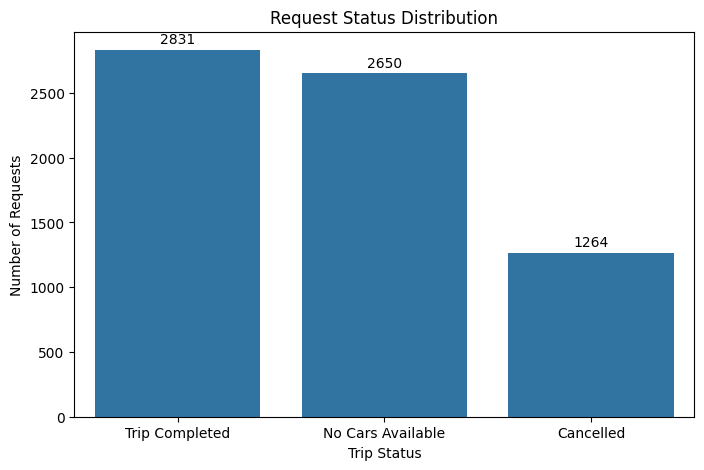

In [71]:
# Chart - 1 visualization code
import matplotlib.pyplot as plt
import seaborn as sns

# Count values of each trip status
status_counts = df['Status'].value_counts()

# Create figure
plt.figure(figsize=(8,5))

# Create bar chart
sns.barplot(
    x=status_counts.index,
    y=status_counts.values
)

# Add labels and title
plt.title('Request Status Distribution')
plt.xlabel('Trip Status')
plt.ylabel('Number of Requests')

# Show values on top of bars
for i, value in enumerate(status_counts.values):
    plt.text(i, value + 50, str(value), ha='center')

# Display chart
plt.show()

##### 1. Why did you pick the specific chart?

I have picked this chart for request status distribution

##### 2. What is/are the insight(s) found from the chart?

A large portion of ride requests are not successfully completed.
“No Cars Available” forms a major share of failed requests.
Cancellations are also significantly high.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Uber is facing a strong demand-supply imbalance.
Driver availability is insufficient during many request periods.
Reducing cancellations and improving driver allocation can increase customer satisfaction and ride completion rates.
es insights indicate operational weaknesses that may negatively affect business growth if not addressed.A large number of requests were marked as “No Cars Available".
Negative Impact:
Customers may shift to competitors due to poor service availability.
Loss of customer trust and satisfaction.
Reduced revenue because potential rides are lost.
Also High Cancellation Rate
Negative Impact:
Poor customer retention
Negative brand reputation
Lower customer loyalty
Reason:
Drivers may cancel rides because of:
Long travel distances
Traffic conditions
Unprofitable routes

#### Chart - 2

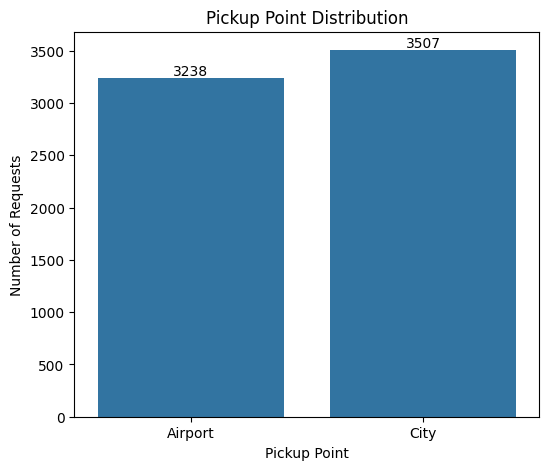

In [72]:
#Count Plot for Pickup point distribution 
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.figure(figsize=(6,5))

# Create countplot
ax= sns.countplot(
    x='Pickup point',
    data=df
)
# Add bar labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# Add title and labels
plt.title('Pickup Point Distribution')
plt.xlabel('Pickup Point')
plt.ylabel('Number of Requests')

# Show chart
plt.show()


##### 1. Why did you pick the specific chart?

To understand where most request originates


##### 2. What is/are the insight(s) found from the chart?

Most ride requests are generated from the City pickup point.
Airport requests are also significantly high.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Increase driver availability near both high-demand pickup points during peak hours.
Use dynamic driver positioning based on demand trends.

#### Chart - 3

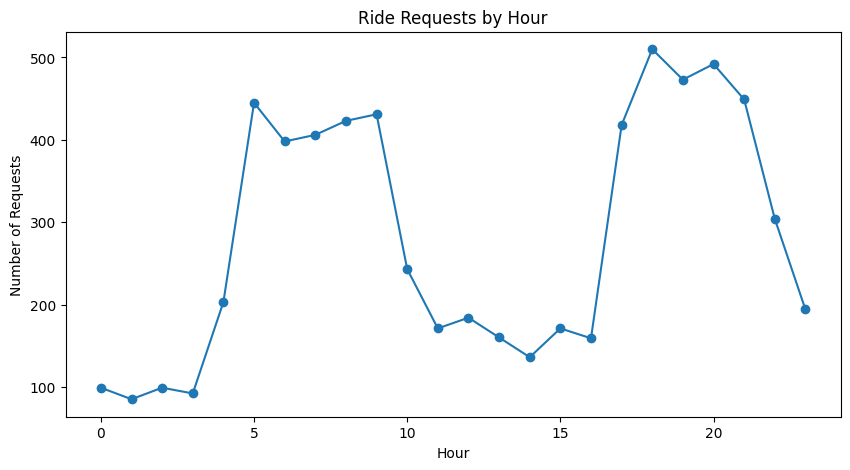

In [73]:
#Line Chart
hourly_requests = df.groupby('Request_Hour').size()

plt.figure(figsize=(10,5))

hourly_requests.plot(kind='line', marker='o')

plt.title('Ride Requests by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Requests')

plt.show()

##### 1. Why did you pick the specific chart?

It shows hourly demand trend for Uber ride requests.

##### 2. What is/are the insight(s) found from the chart?

Ride demand increases sharply during morning and evening hours.
Evening demand is slightly higher than morning demand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Uber should increase driver availability during peak commuting hours.

#### Chart - 4

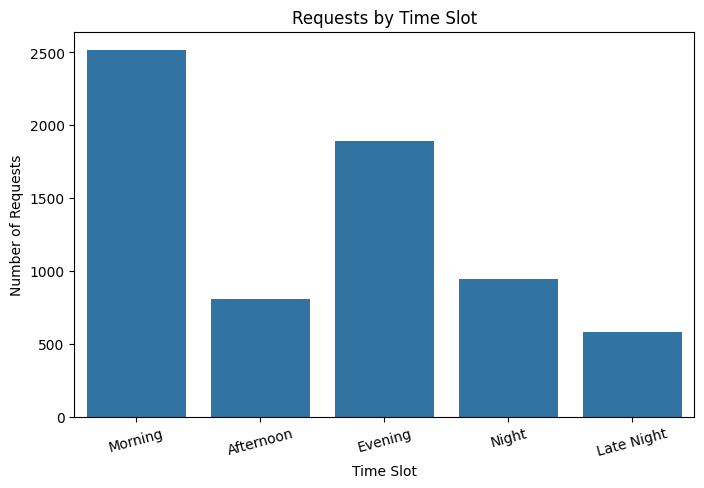

In [74]:
# Chart - 4 visualization code
#Count Plot for Requests by time slot
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(8,5))

# Create countplot
sns.countplot(
    x='Time_Slot',
    data=df,
    order=[
        'Morning',
        'Afternoon',
        'Evening',
        'Night',
        'Late Night'
    ]
)

# Add title and labels
plt.title('Requests by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Number of Requests')

# Rotate labels
plt.xticks(rotation=15)

# Show chart
plt.show()

##### 1. Why did you pick the specific chart?

To analyze ride demand across different parts of the day:
Morning
Afternoon
Evening
Night
Late Night

This helps identify peak demand periods

##### 2. What is/are the insight(s) found from the chart?

Morning has the highest number of ride requests.
Evening demand is also significantly high.
Late NIght demand is comparatively low.
Ride demand peaks during office commuting hours.
Driver shortages are more likely during Morning and Evening slots.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Uber can increase driver availability during peak hours.
Better driver allocation can reduce ride failures.
More completed rides directly increase company revenue.

#### Chart - 5

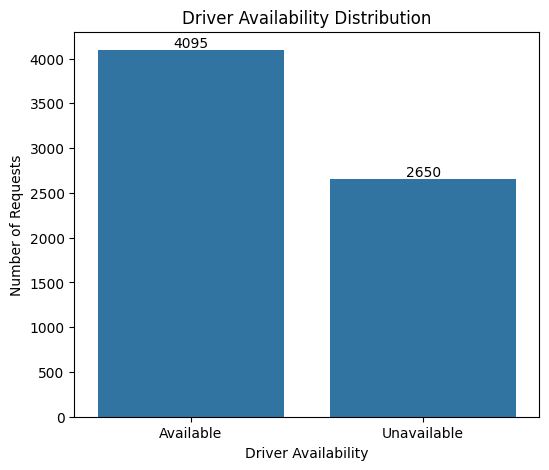

In [75]:
# Chart - 5 Driver Availabilty Distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Create new column
df['Driver_Availability'] = df['Driver id'].apply(
    lambda x: 'Unavailable'
    if pd.isna(x)
    else 'Available'
)

# Plot chart
plt.figure(figsize=(6,5))

ax=sns.countplot(
    x='Driver_Availability',
    data=df
)
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# Add title and labels
plt.title('Driver Availability Distribution')
plt.xlabel('Driver Availability')
plt.ylabel('Number of Requests')

plt.show()

##### 1. Why did you pick the specific chart?

this bar chart tell us that How many requests had drivers available vs unavailable

##### 2. What is/are the insight(s) found from the chart?

A significant number of ride requests faced driver unavailability.
Driver shortages contribute heavily to:

“No Cars Available” cases
Unfulfilled customer demand
Lost revenue opportunities

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


The chart helps identify whether enough drivers are available to fulfill customer ride requests. Understanding driver availability is important because it directly affects ride completion, customer satisfaction, and company revenue.

. High Driver Unavailability

A large number of requests fall under the “Unavailable” category.
Negative Impact:
Customers cannot book rides successfully.
Users may switch to competitors.
Customer trust decreases.

#### Chart - 6

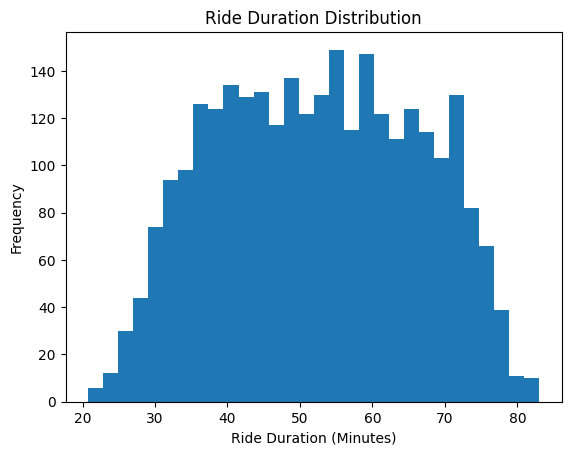

In [76]:
completed = df[df['Status'] == 'Trip Completed'].copy()

plt.hist(
    completed['Ride_Duration_Minutes'],
    bins=30
)

plt.title('Ride Duration Distribution')
plt.xlabel('Ride Duration (Minutes)')
plt.ylabel('Frequency')

plt.show()

### 1. Why did you pick the specific chart?

The Histogram displays the distribution of ride distribution in minute  which help me to analyze the how many rides are of short distance and longest distance rides.

##### 2. What is/are the insight(s) found from the chart


Key Insights:Most of the ride falls between 40 and 70 minutes,with a noticible peak around 50 minute marks.
Range:The duration range from approx. 20 Minutes to 80 Minutes.

#### 3. Will the gained insights help creating a positive business impact? 
 Are there any insights that lead to negative growth? Justify with specific reason.

### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the gained insights can help create a positive business impact by understanding customer ride patterns and operational efficiency. The ride duration distribution helps identify the most common trip durations, enabling Uber to optimize driver allocation, improve route planning, and reduce customer waiting time. Medium-duration trips forming the majority of requests indicate stable customer usage patterns and help in forecasting demand more effectively.

The analysis also supports better operational planning during peak hours, as understanding ride duration trends can help improve driver availability and reduce unfulfilled requests. Efficient ride allocation can enhance customer satisfaction and increase completed trips, positively affecting revenue generation.

However, certain insights may indicate negative operational growth. If a significant number of rides have unusually long durations, it may suggest traffic congestion, inefficient routing, or driver delays, which can reduce driver efficiency and increase customer dissatisfaction. Similarly, a high concentration of short-duration cancelled rides may indicate driver unwillingness to accept low-value trips, contributing to higher cancellation rates and operational inefficiencies.

Therefore, the ride duration analysis helps identify both operational strengths and areas requiring improvement to enhance overall service quality and business performance.


#### Chart - 7

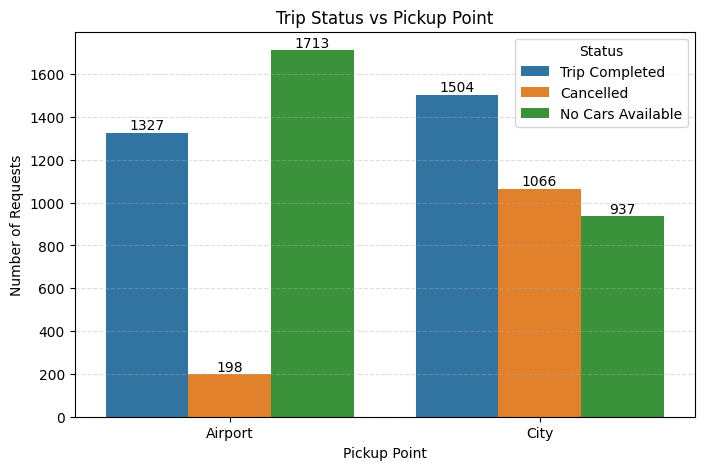

In [77]:
# Chart - 7 Grouped Bar Chart  Trip Status Vs Pickup point
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.figure(figsize=(8,5))

# Plot grouped bar chart
ax = sns.countplot(
    x='Pickup point',
    hue='Status',
    data=df
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# Add title and labels
plt.title('Trip Status vs Pickup Point')
plt.xlabel('Pickup Point')
plt.ylabel('Number of Requests')

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Show chart
plt.show()

##### 1. Why did you pick the specific chart?

Comparison of trip outcomes between City and Airport pickup locations.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
City pickup points experience more trip cancellations.
Airport pickup points show a very high number of “No Cars Available” cases.
Business Insight
Airport locations suffer from severe driver shortages.
City areas face operational inefficiencies leading to cancellations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer HerePositive Impact

The insights help Uber:

optimize driver allocation
reduce unfulfilled requests
improve customer satisfaction
increase ride completion rates
Negative Growth Indicators
High Airport “No Cars Available”
Impact:
Lost customers
Reduced revenue
Poor user experience
Reason:

Demand exceeds available driver supply near airports.

High City Cancellations
Impact:
Lower customer trust
Increased ride failures
Negative brand perception
Reason:

Drivers may cancel due to traffic, long distance, or low profitability.

#### Chart - 8

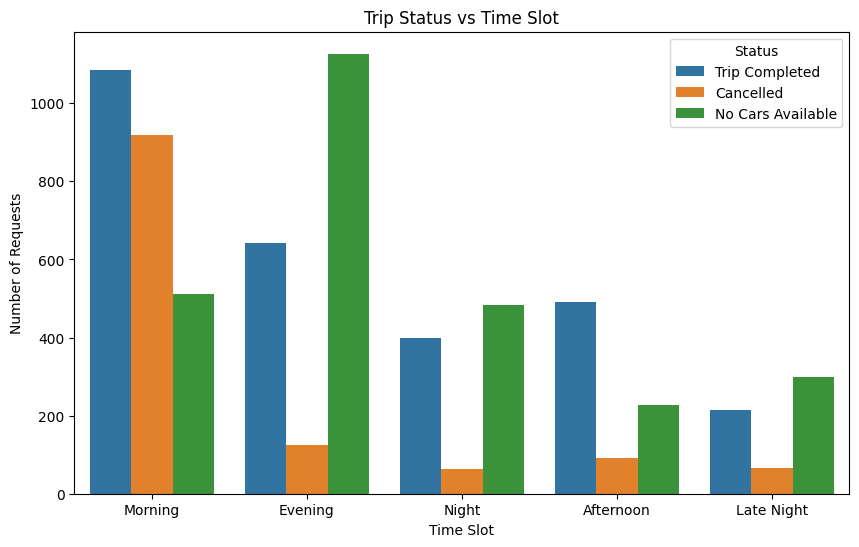

In [78]:
# Bar Graph for Trip tatus Vs Time Slot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Time_Slot',
    hue='Status'
)

plt.title('Trip Status vs Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Number of Requests')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.This is one of the most important analyses in Uber project because it helps identify:

When cancellations happen most
When cars are unavailable most
Peak demand hours
Demand-supply gaps

##### 2. What is/are the insight(s) found from the chart?

Answer Here 1. Morning Time Slot Shows maximum "Cancellations" 
Possible reasons:
Heavy traffic congestion.
Drivers rejecting long-distance rides.
Driver shift ending periods.
2.. Evening Time Slot Shows High “No Cars Available”
3.Late Night Demand is Relatively Low

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights generated from this analysis can create a significant positive business impact because they help identify operational inefficiencies and improve decision-making.
1. Improved Driver Allocation
Demand is highest during:
Morning hours
Evening hours
Airport pickup requests
Deploy more drivers during peak hours
Position drivers strategically near airports and city hotspots will result in Higher trip completion rates
Reduced customer waiting time
Better operational efficiency
2. Reduction in Ride Cancellations
Insight:
Morning time show higher cancellation rates.

Business Impact:

Uber can:

Introduce driver incentives
Optimize route matching
Reduce driver-side trip rejection

Result:

Better customer satisfaction
Increased customer retention
Improved brand trust
4. Increased Revenue Opportunities
Insight:

Many requests remain unfulfilled during peak periods.

Business Impact:

Meeting those missed requests can:

Increase completed rides
Improve revenue generation
Maximize platform utilization
Yes. Some insights indicate serious operational issues that may negatively affect business growth if not addressed.

Negative Growth Indicators
1. High “No Cars Available” Requests
Insight:

A large number of requests fail because drivers are unavailable.

Why This Is Negative:

This leads to:

Lost revenue opportunities
Customer frustration
Reduced platform trust
2.Demand-Supply Imbalance
Insight:

Demand exceeds supply during critical time slots.

Why This Is Negative:

Operational inefficiency causes:

Unfulfilled requests
Driver overload
Poor resource management

#### Chart - 9

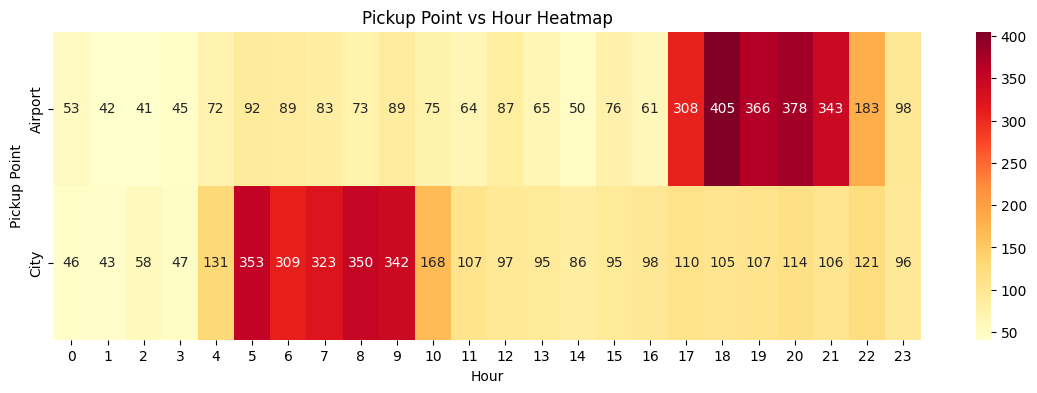

In [79]:
# Chart - 9 Heatmap for Request per hour at different Pickup point 
# visualization code
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create pivot table
pickup_hour = df.pivot_table(
    index='Pickup point',
    columns='Request_Hour',
    aggfunc='size',
    fill_value=0
)

# Create figure
plt.figure(figsize=(14,4))

# Plot heatmap
sns.heatmap(
    pickup_hour,
    annot=True,
    fmt='d',
    cmap='YlOrRd'
)

# Add title
plt.title('Pickup Point vs Hour Heatmap')

# Labels
plt.xlabel('Hour')
plt.ylabel('Pickup Point')

# Show chart
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. Heatmap is an excellent for Pickup point Vs Hour Analysis beacuse it helps visualize 
Demand intensity that is dardker color shows higher demand
Peak hours
Location-wise request concenteration that is "At which hours do city and airport requests peak ?"

##### 2. What is/are the insight(s) found from the chart?

City demand is highest during morning office hours.
Airport demand peaks during evening and night hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights from the “Pickup Point vs Hour” analysis can create a strong positive business impact for Uber because they help identify location-based demand patterns across different hours of the day.

This analysis allows Uber to understand:

when demand is highest
which pickup points face heavy traffic
where driver shortages are likely to occur
Positive Business Impacts
1. Better Driver Allocation

The analysis shows that:

City demand peaks during morning office hours
Airport demand increases during evening
Uber can deploy drivers strategically based on location and time.

Result:
Reduced waiting time
Higher ride completion rate
Improved operational efficiency
Reduced Demand-Supply Gap

The heatmap/line chart helps identify high-demand hours where supply is insufficient.

Business Impact:

Uber can proactively manage driver supply during peak hours.

Result:

Lower “No Cars Available” cases and more successful rides.
Reduced Demand-Supply Gap

The heatmap/line chart helps identify high-demand hours where supply is insufficient.

Business Impact:

Uber can proactively manage driver supply during peak hours.

Result:

Lower “No Cars Available” cases and more successful rides.
Insights Leading to Negative Growth

Yes, some insights indicate operational weaknesses that may negatively impact business growth if not addressed.

1. Airport Driver Shortage During Evening Hours
Negative Impact:
Increased “No Cars Available” cases
Customer frustration
Revenue loss
2. High City Demand Pressure During Morning Hours

City pickup requests increase sharply during office commuting hours.

Negative Impact:
Ride delays
More cancellations
Reduced service quality


#### Chart - 10

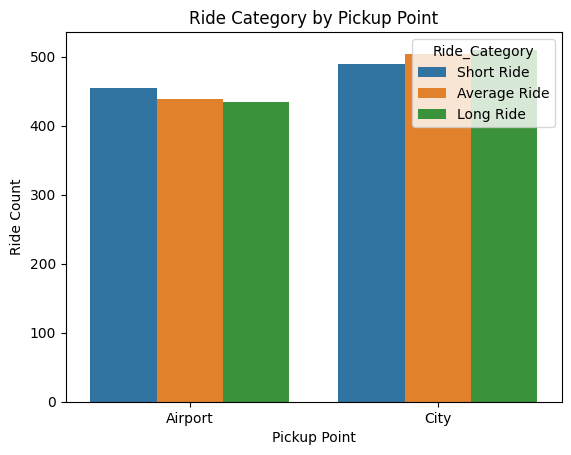

In [80]:
#Different Ride Category(In terms of Ride_duration_minutes)Vs Pickup Point
completed = df[df['Status'] == 'Trip Completed'].copy()
completed['Ride_Category'] = pd.qcut(
    completed['Ride_Duration_Minutes'],
    q=3,
    labels=['Short Ride','Average Ride','Long Ride']
)
completed['Ride_Category'].value_counts()
pd.crosstab(
    completed['Pickup point'],
    completed['Ride_Category']
)
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='Pickup point',
    hue='Ride_Category',
    data=df
)

plt.title('Ride Category by Pickup Point')
plt.xlabel('Pickup Point')
plt.ylabel('Ride Count')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.Because it clearly compares:

ride categories
across pickup locations

##### 2. What is/are the insight(s) found from the chart?

1. City Pickup Requests Are Slightly Higher Overall
2. Airport Ride Categories Are More Balanced
3. Long Rides Are Slightly More Common in City Pickups.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.



1. Better Driver Allocation

The analysis shows different ride duration patterns across:

Airport
City

Uber can use this insight to:

allocate drivers more efficiently
position drivers in high-demand locations
reduce customer waiting time
Business Impact
improved ride fulfillment
faster service
higher customer satisfaction
2. Improved Demand Forecasting

Since average rides dominate city pickups, Uber can:

predict demand more accurately
prepare drivers during peak periods
Business Impact
reduced operational inefficiency
improved trip completion rate
optimized driver utilization
3. Enhanced Customer Experience

Understanding ride duration patterns helps Uber:

estimate ride time better
improve route planning
minimize delays
Business Impact
improved customer trust
higher retention rate
better user experience
4. Revenue Optimization

Longer rides generally generate:

higher fares
increased revenue

Identifying locations with more long-duration rides helps Uber:

strategically position drivers
maximize earning opportunities
Business Impact
increased revenue generation
improved driver earnings


Insights That May Lead to Negative Growth
1. Driver Shortage During High Demand

If analysis shows:

high “No Cars Available”
long waiting times

then it indicates demand-supply imbalance.

Negative Impact
customer dissatisfaction
app abandonment
loss of loyal users
Reason

Customers may switch to competitors if rides are unavailable frequently.

2. High Ride Cancellations

If certain pickup points or time slots show high cancellations:

Negative Impact
reduced customer trust
lower trip completion rates
negative brand image
Reason

Frequent cancellations create poor customer experience.

3. Long Ride Durations During Peak Hours

If ride durations increase significantly during rush hours:

Negative Impact
operational inefficiency
reduced ride turnover
fewer completed trips per driver
Reason

Drivers spend more time per trip, reducing availability for new customers.

4. Uneven Demand Distribution

If one location experiences consistently higher demand:

Negative Impact
inefficient resource utilization
localized driver shortages
Reason

Improper driver distribution can reduce service quality.

#### Chart - 11

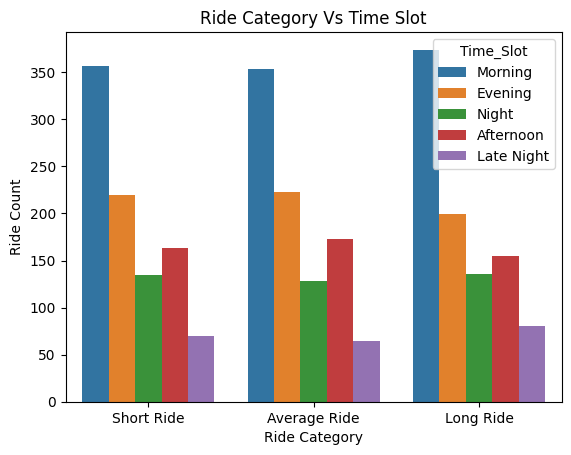

In [81]:
# Chart - 11 visualization codeRide Category Vs Time slot 
completed = df[df['Status'] == 'Trip Completed'].copy()
completed['Ride_Category'] = pd.qcut(
    completed['Ride_Duration_Minutes'],
    q=3,
    labels=['Short Ride','Average Ride','Long Ride']
)
completed['Ride_Category'].value_counts()
sns.countplot(
    x='Ride_Category',
    hue='Time_Slot',
    data=completed
)

plt.title('Ride Category Vs Time Slot')
plt.xlabel('Ride Category')
plt.ylabel('Ride Count')

plt.show()


##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

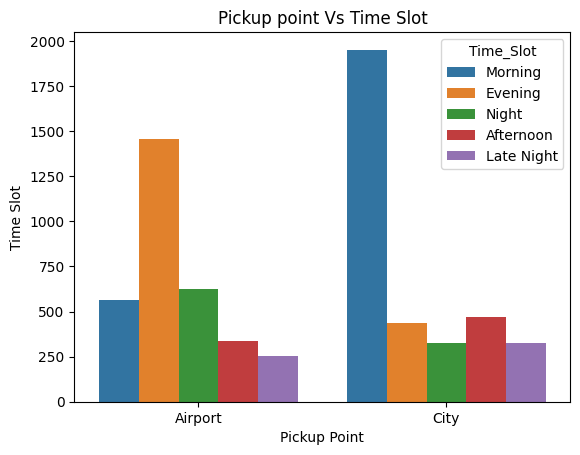

In [82]:
# Chart - 12 visualization code 
sns.countplot(
    x='Pickup point',
    hue='Time_Slot',
    data=df
)

plt.title('Pickup point Vs Time Slot')
plt.xlabel('Pickup Point')
plt.ylabel('Time Slot')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Insights from the Chart: Pickup Point vs Time Slot
This chart shows the distribution of ride categories across different time slots in the Uber Technologies dataset.
The time slots are:
Morning, Afternoon, Evening, Night and Late Night and the ride categories are:Short Ride, Average Ride & Long Ride
1. Morning Time Slot Has the Highest Ride Demand
2. Long Rides Are Most Common in the Morning
3. Evening Demand Is Also Significant
Evening rides show relatively high counts, especially:Average rides,Short rides
Late Night Has the Lowest Ride Activity
All ride categories show minimum counts during late night.
“Customer ride demand decreases significantly during late-night hours.”

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — Strong Positive Business Impact

These insights can help Uber Technolgy
1. Driver Allocation Optimization
Since morning and evening are peak demand periods, Uber can:
deploy more drivers
reduce customer waiting time
improve ride fulfillment
Positive Impact
higher trip completion rate
improved customer satisfaction
2. Better Demand Forecasting Understanding ride demand by time slot helps:
predict peak traffic periods
manage driver supply proactively
Positive Impact
reduced operational inefficiency
better resource utilization
3. Increased Revenue Opportunities
Long rides during morning hours can generate:
higher fares
increased revenue
Uber can strategically:
incentivize drivers
improve ride availability during these hours
Positive Impact
increased company revenue
improved driver earnings
4. Improved Customer Experience By preparing for peak-hour demand:
cancellations can decrease
ride availability can improve
Positive Impact
stronger customer retention
improved brand loyalty
There are Some Insights Highlight Operational Risks
1. Heavy Morning Demand May Cause Driver Shortage
Morning rides are significantly high.
If driver supply is insufficient:
Negative Impact
“No Cars Available”
long waiting times
customer frustration
Reason

Demand may exceed driver availability during rush hours.

2. Peak-Hour Traffic Can Increase Ride Duration

Long rides during morning periods may indicate:

traffic congestion
operational delays
Negative Impact
reduced driver efficiency
fewer trips completed per driver
Reason

Drivers spend more time on each trip.

3. Uneven Ride Distribution Across Time Slots

Late-night demand is very low.

Negative Impact
idle drivers during low-demand periods
inefficient driver utilization
Reason

Drivers may remain inactive during off-peak hours.

4. High Dependence on Peak Hours

Most demand is concentrated in:

Morning
Evening
Negative Impact

Revenue may fluctuate heavily depending on:

rush-hour demand
daily commuting patterns
Final Business Conclusion

“The analysis revealed that ride demand is highest during morning and evening periods, with long rides dominating morning travel patterns. These insights can help Uber improve driver allocation, demand forecasting, and customer satisfaction. However, peak-hour demand concentration and potential driver shortages may negatively impact operational efficiency and customer experience if not managed effectively.”

#### Chart - 13

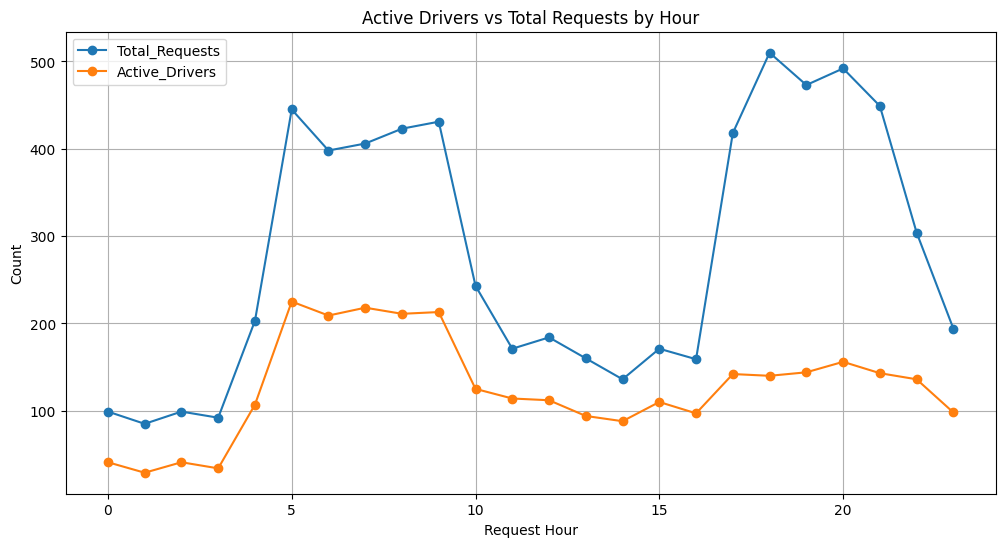

In [83]:
requests_per_hour = df.groupby('Request_Hour').size()
active_drivers = df.groupby('Request_Hour')['Driver id'].nunique()
#combine Both
comparison_df = pd.DataFrame({
    'Total_Requests': requests_per_hour,
    'Active_Drivers': active_drivers
})
#Create Line Chart
import matplotlib.pyplot as plt

comparison_df.plot(
    figsize=(12,6),
    marker='o'
)

plt.title('Active Drivers vs Total Requests by Hour')

plt.xlabel('Request Hour')
plt.ylabel('Count')

plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

This Line Chart shows realtionship between demand and supply over 24 hours period

##### 2. What is/are the insight(s) found from the chart?

Morning Peak Hour there is a sharp spike in Total Requests reaching nearly 500,while Active Driver remains significantly lower(around 200).This indicates suply shortage during the morning rush.
After Noon both requests and active drivers drops significantly suggesting lower demand and driver availablity during afternoon
Evening Surge total requests climb again in evening.,while active driverremain significantly lower around 150
there is huge demand and supply gaph during peak hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the gained insights will create a highly positive business impact if acted upon, while failing to address specific trends visible in the data will lead to negative growth.
Positive Business Impact :Acting on these insights directly drives revenue and retention through specific mechanisms:
Maximizes Revenue Capture: Aligning driver supply with the 18:00 demand peak ensures you capture fares that are currently being lost to unfulfilled ride requests.
Improves Customer Retention: Reducing the massive supply gap during peak hours lowers passenger wait times and booking cancellation rates, preventing users from switching to competitors.
Optimizes Driver Earnings: Directing drivers to peak windows increases their hourly utilization rate, boosting their satisfaction and reducing driver churn.
Insights Leading to Negative Growth (Risks)
The graph highlights distinct operational realities that will trigger negative business growth if left unmanaged.

Severe Driver Burnout and Churn (Evening Deficit):Reason: Between 17:00 and 21:00, demand skyorockets to its highest levels (over 500 requests), but the driver count remains completely flat and static (around 140 drivers).
Impact: This extreme imbalance means the few active drivers will be bombarded with non-stop requests and potential gridlock. Without surge incentives, this overwhelming workload leads to high driver frustration, burnout, and eventual platform abandonment.
Damaged Brand Loyalty (The Morning Drop-off):
Reason: At 05:00, requests instantly jump from under 100 to 450, while driver supply only climbs marginally.
Impact: Commuters opening the app at 5:00 AM will face immediate ride unavailablity or extreme wait times. Because morning commute schedules are strict, a failure to provide rides at this exact hour permanently destroys user trust, causing negative customer growth.
Wasted Operational Costs (Midday Glut):
Reason: Between 11:00 and 14:00, ride requests plummet significantly, yet the driver count stays relatively high and flat.Impact: Too many drivers are competing for too few rides. Drivers will sit idle, earning little to no money during these hours. Low hourly earnings lead to negative word-of-mouth, damaging your driver acquisition pipeline.

#### Chart - 14 - Correlation Heatmap

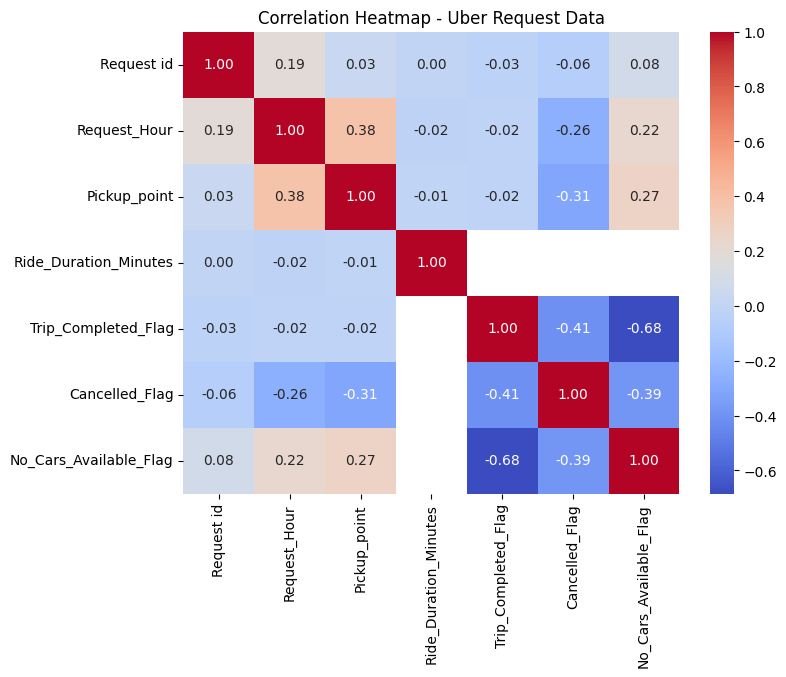

In [84]:
# Convert Pickup Point into numeric
df['Trip_Completed_Flag'] = df['Status'].apply(
    lambda x: 1 if x == 'Trip Completed' else 0
)
df['Cancelled_Flag'] = df['Status'].apply(
    lambda x: 1 if x == 'Cancelled' else 0
)
df['No_Cars_Available_Flag'] = df['Status'].apply(
    lambda x: 1 if x == 'No Cars Available' else 0
)



df['Pickup_point'] = df['Pickup point'].map({
    'Airport': 1,
    'City': 0
})


corr_data = df[[ 'Request id','Request_Hour','Pickup_point','Ride_Duration_Minutes','Trip_Completed_Flag','Cancelled_Flag','No_Cars_Available_Flag']]

# Correlation matrix
corr_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap - Uber Request Data')
plt.show()

##### 1. Why did you pick the specific chart?

The correlation heatmap helps identify relationships and dependencies between multiple numerical features in the Uber ride request dataset at a single glance.

##### 2. What is/are the insight(s) found from the chart?

Key Insights from the Correlation Heatmap
1. Request Hour vs Pickup Point → Moderate Positive Correlation (0.38)
Insight: As hour increase the request of ride especially in evening increase at airport .As i encoded Pickup point as 0 for City and 1 for Airport
2. Request Hour vs Cancelled Flag → Negative Correlation (-0.26)
Insight:As request hours change, cancellations show a moderate inverse relationship.As time increase cancellation ride decrease overall that means in morning hour there is more ride cancellation.
3. Request Hour vs No Cars Flag → Positive Correlation (0.22)
Insights: As hour increase Car unavailbilty increase that means in Evening there is more Car unavailabilty.
4. Pickup Point vs Cancelled Flag → Moderate Negative Correlation (-0.31)
Insights:Cancellation behavior varies by pickup location.
Interpretation:
One pickup point (likely Airport or City) faces comparatively more cancellations.As I encode 0 to City and 1 to Airport so when we move from city to Airport Request cancellation decreases.
Business Impact:Uber can improve driver assignment strategies at problematic pickup location
5. Pickup Point vs No Cars Flag → Positive Correlation (0.27)
Insight:Certain pickup locations are more associated with driver shortages.

Business Meaning:Airport or City areas may have supply-demand imbalance.
Business Impact:Driver distribution can be optimized geographically.
6. Trip Completed Flag vs No Cars Flag → Strong Negative Correlation (-0.68)
Most Important Insight
Insight:When “No Cars Available” increases, trip completion decreases significantly.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the gained insights will help create a positive business impact by highlighting specific operational bottlenecks that Uber can fix to increase completed trips and revenue.
Optimizing Vehicle Supply: The positive correlation between Pickup_point and No_Cars_Available_Flag (0.27) and Request_Hour and No_Cars_Available_Flag (0.22) pinpoints exactly when and where supply shortages happen. Management can deploy targeted driver incentives (like surge pricing or guaranteed hourly rates) to these specific locations and times to balance supply and demand.Preventing Lost Revenue: The strongest negative correlation in the dataset is between Trip_Completed_Flag and No_Cars_Available_Flag (-0.68). This proves that a lack of vehicles is the primary driver of unfulfilled rides. Solving the vehicle availability problem will directly convert failed requests into completed, revenue-generating trips.Insights Revealing Potential Negative GrowthWhile data itself is neutral, the following relationships reveal systemic issues that actively hurt business growth:The Supply-Deficit Trap (-0.68 Correlation): The severe negative correlation between No_Cars_Available_Flag and Trip_Completed_Flag (-0.68) indicates a structural failure to meet demand. When customers repeatedly open the app and see "No Cars Available," user retention drops. This leads to negative growth because frustrated riders permanently switch to competitors.The Cancellation Chain (-0.31 and -0.26 Correlation): Cancelled_Flag shows a negative correlation with both Pickup_point (-0.31) and Request_Hour (-0.26). This indicates that driver or rider cancellations are heavily concentrated during specific hours and at particular pickup locations (likely due to long wait times or heavy traffic). Frequent cancellations lead to wasted driver time, lower driver earnings, and an overall decline in platform trust, dragging down business volume

#### Chart - 15 Pair Plot visualization code


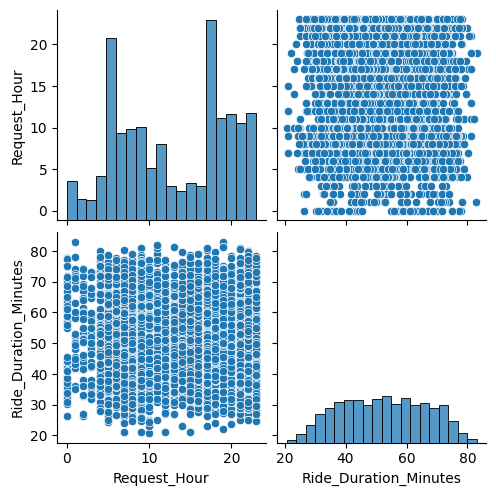

In [85]:
cols = [
    'Request_Hour',
    'Ride_Duration_Minutes']

sns.pairplot(df[cols])

plt.show()

##### 1. Why did you pick the specific chart?

Pair Plot is used during Exploratory Data Analysis (EDA) to:
quickly understand relationships, distributions, and patterns between multiple numerical variables.
A pairplot help us to understand distributions i.e to see how each variable is spread .Detect Relationships ,detect clusters and identify outliers 
I used variables like:

Hour
Ride Duration


Pair Plot helps check:

whether cancellations happen at certain hours?
whether ride duration affects completion?
whether patterns exist among operational variables.

##### 2. What is/are the insight(s) found from the chart?

1.No Strong Correlation Between Request Hour and Ride Duration. In the scatter plot between:
Request_Hour
Ride_Duration_Minutes
the points are spread randomly.
3. Ride Duration Mostly Falls Between ~25–80 Minutes
From the Ride_Duration_Minutes histogram:
Most rides appear concentrated around:
30–75 minutes.Most trips have medium ride durations, while extremely short or extremely long trips are less common.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis of Uber ride request data, several recommendations can help achieve the business objective of reducing cancellations, minimizing unfulfilled requests, and improving customer satisfaction.

1. Increase Driver Availability During Peak Hours
   The analysis showed higher ride requests and increased “No Cars Available” incidents during peak commuting hours, especially in morning and evening time slots. Uber should increase active driver availability during these periods through incentive programs, surge pricing, or optimized driver scheduling.

2. Improve Driver Allocation at High-Demand Locations
   Certain pickup points, such as airport and city hotspots, experienced higher demand and cancellations. Implementing location-based driver allocation and predictive demand planning can help reduce waiting time and improve trip completion rates.

3. Reduce Ride Cancellations
   Higher cancellation rates negatively impact customer experience and operational efficiency. Uber can reduce cancellations by improving driver-trip matching algorithms, monitoring driver cancellation behavior, and offering incentives for ride acceptance during high-demand periods.

4. Use Demand Forecasting for Better Operational Planning
   Historical ride request trends by hour and day can be used to forecast demand patterns. This will help the company proactively allocate drivers and resources to areas with expected high ride demand.

5. Enhance Customer Experience Through Faster Ride Fulfillment
   Reducing unfulfilled requests and improving ride completion rates can increase customer trust and retention. Faster ride allocation and better driver availability can directly improve overall customer satisfaction.

Overall, the analysis highlights that improving driver supply management, operational planning, and demand forecasting can significantly reduce demand-supply gaps and enhance Uber’s operational performance and business growth.


# **Conclusion**

## Conclusion
The analysis identified significant demand-supply gaps during peak hours, leading to increased ride cancellations and “No Cars Available” cases.
Ride requests were highly concentrated during morning and evening peak hours, indicating strong commuter-based demand patterns.
The majority of rides had medium trip durations, showing stable customer ride behavior across most operational periods.
Driver availability was insufficient during high-demand periods, especially during evening hours, which negatively impacted trip completion rates.
The Airport pickup point experienced the highest demand during evening and late-night hours, particularly between:
5 PM – 11 PM

This suggests increased airport travel demand during evening arrivals and departures.

The City pickup point showed highest ride demand during morning office commuting hours, mainly between:
5 AM – 10 AM

indicating strong urban work-related transportation demand.

Cancellation rates increased during peak demand periods, suggesting operational inefficiencies and inadequate driver allocation during busy hours.
“No Cars Available” requests were significantly higher during evening peak hours, confirming a shortage of active drivers relative to customer demand.
Day-wise analysis showed variation in ride demand across weekdays and weekends, helping identify high operational workload periods.
Correlation and pair plot analysis indicated limited strong linear relationships among operational variables, suggesting that ride demand behavior is influenced by multiple dynamic factors.
The insights gained from the analysis can help improve:
driver allocation strategies
peak-hour planning
customer satisfaction
operational efficiency
ride completion rates
Implementing better driver distribution during peak demand periods can reduce cancellations and improve overall business performance.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***